Exploratory Data Analysis 

In [1]:
import ast 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset


#Load the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\abbes\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filter for spain data analysts

In [ ]:
df_Da_spain = df[(df['job_country'] == 'Spain') & (df['job_title_short'] == 'Data Analyst')]
df_Da_spain

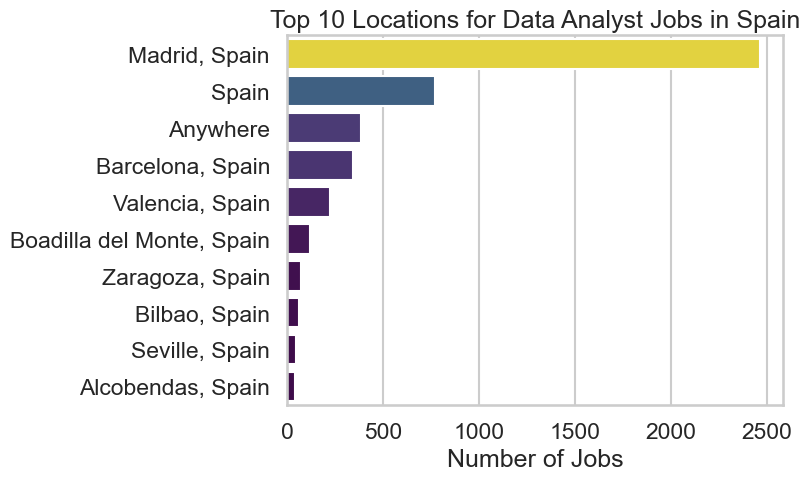

In [67]:
df_plot =df_Da_spain['job_location'].value_counts().head(10).to_frame()
sns.set_style('whitegrid')
sns.barplot(data=df_plot, x='count', y='job_location' , hue='count' , palette='viridis' , legend=False)
plt.title('Top 10 Locations for Data Analyst Jobs in Spain')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

# which city pay more for data analysts 

In [ ]:
# Correct way to select both columns
df_Da_spain[['job_location', 'salary_year_avg']].dropna().head()

# Average salary by city (top 10 by average salary)
df_Da_spain.groupby('job_location', as_index=False)['salary_year_avg'] \
    .mean() \
    .sort_values('salary_year_avg', ascending=False) \
    .head(10)

KeyError: 'salary_year_avg'

Job Details in spain 

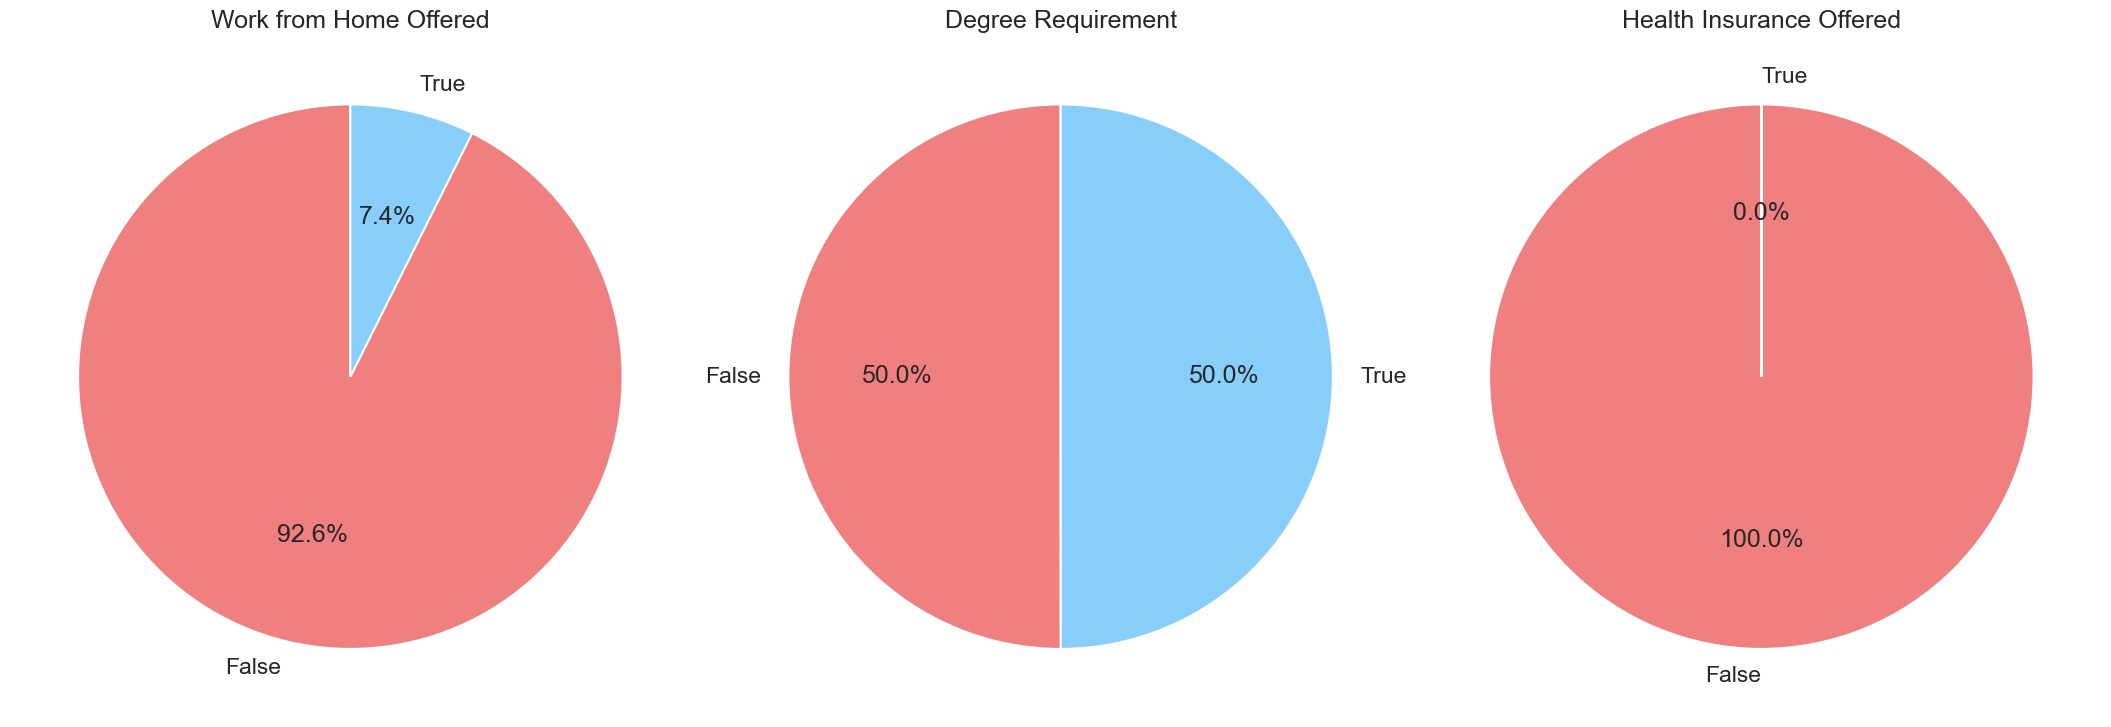

In [107]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
    }

fig, ax = plt.subplots(1, 3, figsize=(21, 25) , constrained_layout=True , sharey=True ) # sharey= true mean that the y-axis will be shared across all subplots, ensuring that they have the same scale and making it easier to compare the values across the different pie charts.
# to change coleur we need to add the parameter colors = ['color1', 'color2'] in the pie function
colors = ['lightcoral', 'lightskyblue']
for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_Da_spain[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90, colors=colors)
    ax[i].set_title(title)

plt.show()

Companies Looking for data analysts in spain 

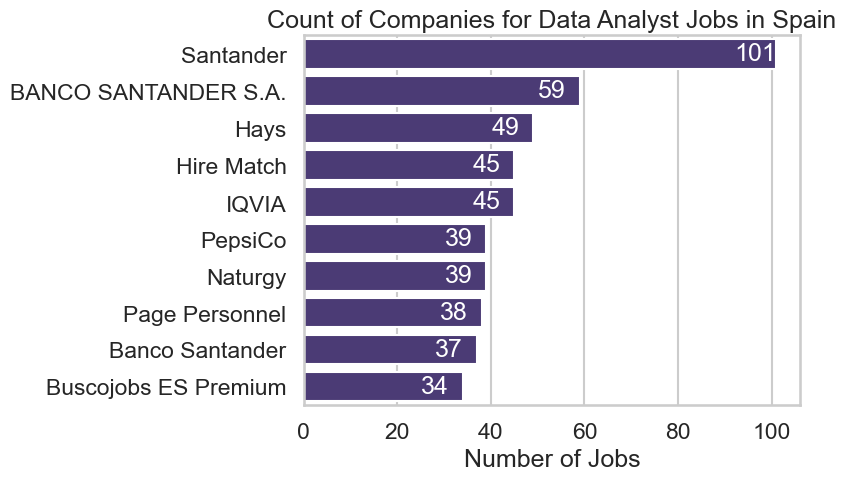

In [103]:
df_plot = df_Da_spain['company_name'].value_counts().head(10).to_frame()

sns.set_style('whitegrid')

ax = sns.barplot(
    data=df_plot,
    x='count',
    y='company_name'
)

ax.bar_label(
    ax.containers[0],
    fmt='%d',
    padding=-30,
    color='white',
    fontweight='normal' # we can use bold or font
)

plt.title('Count of Companies for Data Analyst Jobs in Spain')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

In [104]:
df_Da_spain

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
395,Data Analyst,Digital Analyst,"Madrid, Spain",via BeBee,Full-time,False,Spain,2023-12-19 13:15:13,True,False,Spain,None,NaN,NaN,Nigel Frank International Limited,"[javascript, sql, bigquery]","{'cloud': ['bigquery'], 'programming': ['javas..."
700,Data Analyst,Data Privacy Analyst,Anywhere,via LinkedIn,Full-time,True,Spain,2023-11-02 13:28:42,False,False,Spain,None,NaN,NaN,Ansys,"[gdpr, sharepoint]","{'analyst_tools': ['sharepoint'], 'libraries':..."
771,Data Analyst,Prácticas Analista de Datos | Data Analyst Tra...,"Madrid, Spain",via LinkedIn,Part-time,False,Spain,2023-08-14 13:20:09,False,False,Spain,None,NaN,NaN,ACCOM,"[sql, power bi, excel, dax, tableau]","{'analyst_tools': ['power bi', 'excel', 'dax',..."
1573,Data Analyst,Data Analyst,"Barcelona, Spain",via BeBee,Full-time,False,Spain,2023-12-13 13:48:15,True,False,Spain,None,NaN,NaN,Lodgify,None,None
2740,Data Analyst,ICC-Telemetry Data Analyst,Spain,via BeBee,Full-time,False,Spain,2023-01-21 13:30:54,False,False,Spain,None,NaN,NaN,Takeda,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784506,Data Analyst,Data Analytics y Controlling,"Valencia, Spain",via BeBee,Full-time,False,Spain,2023-09-11 06:26:23,False,False,Spain,None,NaN,NaN,Servinform,"[sql, python, power bi, excel]","{'analyst_tools': ['power bi', 'excel'], 'prog..."
784720,Data Analyst,Junior Scientist,"L'Hospitalet de Llobregat, Spain",via BeBee,Full-time,False,Spain,2023-10-07 06:30:01,False,False,Spain,None,NaN,NaN,IDIBELL,[flow],{'other': ['flow']}
784734,Data Analyst,Data Analytics,"Madrid, Spain",via BeBee,Full-time,False,Spain,2023-09-08 06:18:18,True,False,Spain,None,NaN,NaN,Boston Scientific Corporation,None,None
785112,Data Analyst,Data Analyst,Spain,via Trabajo.org,Full-time,False,Spain,2023-01-10 06:25:50,True,False,Spain,None,NaN,NaN,Kordian Group sp zoo,"[sql, python, azure, aws, looker, jira]","{'analyst_tools': ['looker'], 'async': ['jira'..."


Type of employment for Data Analyst jobs in Spain , Part-time vs Full-time

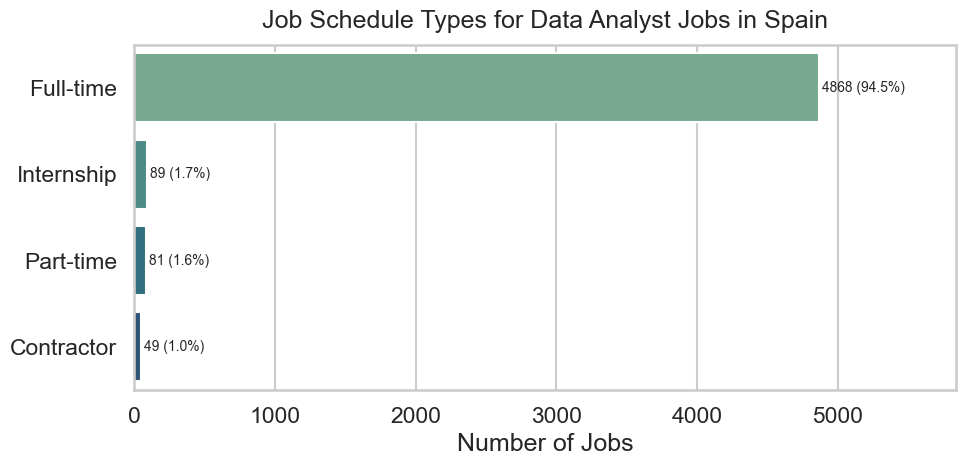

In [138]:
# Prepare top schedule types with counts and percentages
df_plot = df_Da_spain['job_schedule_type'].value_counts().head(4).reset_index()
df_plot['pct'] = (
    df_plot['count'] /
    df_Da_spain['job_schedule_type'].notna().sum()
    * 100
).round(1)
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_plot,
    x='count',
    y='job_schedule_type',
    hue='job_schedule_type',
    palette='crest',
    legend=False,
    ax=ax
)

# Add labels: count + percentage for each bar
for i, row in df_plot.iterrows():
    ax.text(
        row['count'] + 20,
        i,
        f"{row['count']} ({row['pct']}%)",
        va='center',
        fontsize=10
    )

ax.set_title('Job Schedule Types for Data Analyst Jobs in Spain', pad=12)
ax.set_xlabel('Number of Jobs')
ax.set_ylabel('')
ax.set_xlim(0, df_plot['count'].max() * 1.2)
plt.tight_layout()
plt.show()